2631715


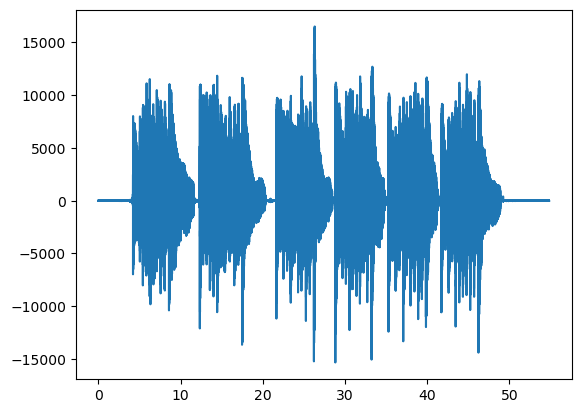

In [14]:
import wave
import numpy
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import filtfilt
from scipy import io
# open the audio file and extract some information
# spf = wave.open('/home/gerald/workspace/src/GuitarMidi-LV2/assets/single-note/Guitar MIDI test.wav','r')
# (nChannels, sampWidth, sampleRate, nFrames, compType, compName) = spf.getparams()

sampleRate,input_signal=io.wavfile.read('/home/gerald/workspace/src/GuitarMidi-LV2/assets/chordsE-A.wav')
audio=input_signal#[:,1];
print(len(audio))
nFrames =input_signal.shape[0]
time=numpy.linspace(0,len(audio)/sampleRate,len(audio))

plt.plot(time, audio, label='Input')



# # extract audio from wav file
# input_signal = spf.readframes(-1)


# input_signal = numpy.fromstring(input_signal)
# spf.close()



# # ceate output file
# wav_out = wave.open("output.wav", "w")
# wav_out.setparams((nChannels, sampWidth, sampleRate, nFrames, compType, compName))

# # write to output file
# wav_out.writeframes(output_signal.tobytes())
# wav_out.close()

# # plot the signals
# t = numpy.linspace(0, nFrames/sampWidth, nFrames, endpoint = False)
# plt.plot(t, input_signal, label='Input')
# plt.plot(t, output_signal, label='Output')
# plt.show()


In [ ]:
import numpy as np
import seaborn as sns
num_harmonics=8
num_frets=13
num_strings=6
class Filter:
    def __init__(self, fret,stringid,harmonic,center_freq, bw,sample_rate):
        self.id=fret*num_strings*num_harmonics+stringid*num_harmonics+harmonic
        self.sample_rate=sample_rate
            
        # create the filter
        N = 2
        nyq = 0.5 * sampleRate
        low = (center_freq-bw/2) / nyq
        high = (center_freq+bw/2) / nyq
        self.b, self.a = signal.butter(N, [low, high], btype='band')
        
    def process(self,input_audio,output_list: np.array):
        output_list[self.id]=np.abs(signal.filtfilt(self.b, self.a, input_audio))


class HarmonicGroup:
    def __init__(self,fret,stringid ,center_freq, bw,sample_rate):
        self.harmonics=[]
        
        for h in range(1,num_harmonics+1):
            self.harmonics.append(Filter(fret,stringid,h-1,center_freq*h,bw,sample_rate))
    
            
    def process(self, input_audio, output_list: np.array):
        res=output_list
        for h in self.harmonics:
            #output_list.append(h.process(input_audio))
            h.process(input_audio,output_list)
            
        return res
    def get_num_filters(self):
        return len(self.harmonics)
          
            
class Fret:
    def __init__(self,fret,s0,s1,s2,s3,s4,s5, bw,sample_rate):
        
        self.strings=[]
        self.strings.append(HarmonicGroup(fret,0,s0,bw,sample_rate))
   
        self.strings.append(HarmonicGroup(fret,1,s1,bw,sample_rate))

        self.strings.append(HarmonicGroup(fret,2,s2,bw,sample_rate))

        self.strings.append(HarmonicGroup(fret,3,s3,bw,sample_rate))

        self.strings.append(HarmonicGroup(fret,4,s4,bw,sample_rate))

        self.strings.append(HarmonicGroup(fret,5,s5,bw,sample_rate))

        
    def process(self, input_audio, output_list: np.array):
    
        for h in self.strings:
            #output_list.append(h.process(input_audio,output_list))
            h.process(input_audio,output_list)
      
    def get_num_filters(self):
        res=0
        for h in self.strings:
            res=res+h.get_num_filters()
            
        return res
            
class FretBoard:
    def __init__(self,bw,sample_rate):
        self.frets=[]
       
        self.frets.append(Fret(0,82,11,147,196,247,329,bw,sample_rate))
        self.frets.append(Fret(1,87,117,156,208,262,349,bw,sample_rate))
        self.frets.append(Fret(2,92,123,165,220,277,370,bw,sample_rate))
        self.frets.append(Fret(3,98,131,175,233,294,392,bw,sample_rate))
        self.frets.append(Fret(4,104,139,185,247,311,415,bw,sample_rate))
        self.frets.append(Fret(5,110,147,196,262,329,440,bw,sample_rate))
        self.frets.append(Fret(6,117,156,208,277,349,466,bw,sample_rate))
        self.frets.append(Fret(7,123,165,220,294,370,494,bw,sample_rate))
        self.frets.append(Fret(8,131,175,233,311,392,523,bw,sample_rate))
        self.frets.append(Fret(9,139,185,247,329,415,554,bw,sample_rate))
        self.frets.append(Fret(10,147,196,262,349,440,587,bw,sample_rate))
        self.frets.append(Fret(11,156,208,277,370,466,622,bw,sample_rate))
        self.frets.append(Fret(12,165,220,294,392,494,659,bw,sample_rate))
        
    def process(self, input_audio, output_list: np.array):
      
        for h in self.frets:
            # output_list.append(h.process(input_audio,output_list))    
            res=h.process(input_audio,output_list)
       
    def get_num_filters(self):
        res=0
        for h in self.frets:
            res=res+h.get_num_filters()
            
        return res

filter =FretBoard(20,sampleRate)
numfilters=filter.get_num_filters()
print('num filters:'+str(numfilters))
audiolength=len(audio)

lencut=50*sampleRate

# lencut=len(audio)
audiocut=audio[:lencut]

output_list=np.zeros((numfilters,len(audiocut)))
# print(output_list.shape)
# output_list=np.expand_dims(output_list, axis=0)
filter.process(audiocut,output_list)
# print(output_list.shape)
# print(len(output_list))
# It's best practice to convert your list of lists to a NumPy array.
# Matplotlib can handle lists of lists directly, but NumPy arrays are
# more efficient and offer more features for data manipulation.
# heatmap_data = output_list#np.array(output_list)
num_cols=output_list.shape[1]
num_rows=output_list.shape[0]
downsample_factor = 1000
# --- Downsampling the data ---
print(f"Downsampling data by a factor of {downsample_factor}...")
# Calculate the new number of columns after downsampling
new_num_cols = num_cols // downsample_factor

# Ensure the original number of columns is a multiple of the downsample_factor
# If not, you might lose some data at the end or need a more complex aggregation.
# For simplicity, we'll slice to a multiple of downsample_factor
effective_cols = new_num_cols * downsample_factor
data_sliced = output_list[:, :effective_cols]
print(data_sliced.shape)
# Reshape the data for averaging:
# -1: infer dimension
# downsample_factor: group columns into blocks
# num_rows: keep rows as isp
# This reshapes (19, M*N) to (19, M, N)
reshaped_data = data_sliced.reshape(num_rows, new_num_cols, downsample_factor)

# Average along the last axis (the downsample_factor axis)
downsampled_data = np.max(reshaped_data, axis=2)

print(f"Downsampled array shape: {downsampled_data.shape}")

# --- Plotting the Heatmap ---
print("Creating heatmap...")
plt.figure(figsize=(20, 8)) # Adjust figure size as needed, especially width for more columns
sns.heatmap(downsampled_data, cmap='viridis', cbar_kws={'label': 'Value'})
plt.title(f'Heatmap of (19, {num_cols}) Array (Downsampled by {downsample_factor})')
plt.xlabel(f'Column Bins (Each bin represents {downsample_factor} original columns)')
plt.ylabel('Row Index')
plt.show()
print("Heatmap displayed.")


num filters:624


In [3]:


import numpy as np

# Original matrix dimensions
rows = 19
cols = 48000

# Create a sample 2D NumPy array (replace with your actual data)
original_matrix = np.zeros((rows,cols))#np.random.rand(rows, cols)

print(f"Original matrix shape: {original_matrix.shape}")

# Desired downsampled columns
downsampled_cols = 480

# Calculate the downsampling factor
downsample_factor = cols // downsampled_cols

# Ensure the downsampling is exact
if cols % downsampled_cols != 0:
    raise ValueError("Original column count must be a multiple of the downsampled column count.")

# Reshape the matrix to group elements along the y-axis, then take the mean
# The idea is:
# 1. Reshape (19, 48000) into (19, 480, 100)
# 2. Take the mean along the last axis (axis=2) to average the 100 elements.
downsampled_matrix = original_matrix.reshape(rows, downsampled_cols, downsample_factor).mean(axis=2)

print(f"Downsampled matrix shape: {downsampled_matrix.shape}")

# You can optionally verify the first few values to see the smoothing effect
# print("\nFirst row of original matrix (first 10 elements):")
# print(original_matrix[0, :10])
# print("\nFirst row of downsampled matrix (first element - should be mean of first 100 of original):")
# print(downsampled_matrix[0, 0])

Original matrix shape: (19, 48000)
Downsampled matrix shape: (19, 480)
